# Arm Movement Analysis
*Suraj Puvvadi*

*04-22-26*

This notebook provides a complete analysis pipeline for **arm-swing biomechanics** using **XSENS motion capture data** exported in `.txt` format.  
It loads 3D segment positions and accelerations (Right/Left Forearms, Feet, Pelvis), applies optional low-pass filtering, and computes a comprehensive set of **kinematic upper limb metrics** describing arm motion and symmetry during gait.

<h2>Imports</h2>

In [33]:
import os
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
import numpy.fft as fft

<h2>Configuration and User-Tunable Parameters</h2>

These global parameters control how accelerometer data is processed throughout the script, which affects all downstream metric calculations.

| Parameter | Default | Meaning | How to tune it |
|------------|----------|----------|----------------|
| **`GLOBAL_FS`** | `60.0` | Sampling frequency (frames per second). | `GLOBAL_FS = 60.0` always because our accelerometer data is sampled at 60 Hz.|
| **`GLOBAL_CUTOFF_HZ`** | `10.0` | Global **low-pass filter cutoff** frequency (Hz). | Choose based on expected motion frequency. Per literature, 8-10 Hz is recommended for arm swing. |
| **`GLOBAL_FILTER_ORDER`** | `4` | Butterworth filter order, which controls how sharp the cutoff is. | 4th order is a gold-standard per published studies; higher order = more phase distortion. |
| **`PEAK_DISTANCE_FRAMES`** | `30` | Minimum frame separation between detected peaks. Prevents double-counting small bumps as extra movements. | Tune ≈ *half the period* of your target motion. At 60 Hz, 30 frames ≈ 0.5 s, so this fits ~1 Hz arm swing. |
| **`TOP_K`** | `3` | Number of top peaks to average when summarizing metrics. | In noisy data, averaging the top 3 helps avoid outliers. |

Papers justifying cutoff frequency of 10 Hz:
- https://doi.org/10.3390/s18103399
- https://doi.org/10.1080/17461391.2014.955131
- https://doi.org/10.3390/s19092186
- https://doi.org/10.3390/s21134580


Butterworth filtering is recommended to use for biomechanical analysis - https://doi.org/10.3390/s21134580

### Global Cutoff vs. Peak Distance

Both parameters help remove non-arm signal noise, but they act at different stages of processing:

| Stage | Purpose | Acts on | Example |
|-------|----------|---------|---------|
| **Low-pass filter (`GLOBAL_CUTOFF_HZ`)** | Smooths the signal by removing high-frequency noise. | Continuous waveform. | “Clean the signal before analysis.” |
| **Peak-distance rule (`PEAK_DISTANCE_FRAMES`)** | Ignores peaks that occur too close in time to be real events. | Discrete event detection. | “Once the signal is smooth, don’t double-count a swing.” |




In [34]:
# Global parameters

GLOBAL_FS = 60.0              # sampling frequency (Hz) — usually from file header (default 60)
GLOBAL_CUTOFF_HZ = 10.0       # global low-pass cutoff (Hz). Change this to apply to *all* metrics.
GLOBAL_FILTER_ORDER = 4       # butterworth order
PEAK_DISTANCE_FRAMES = 30     # default minimum distance between peaks (frames)
TOP_K = 3                     # top-k mean for peak summaries


In [35]:
# Butterworth filtering methods

def butter_lowpass_coeffs(cutoff_hz, fs, order=4):
    """Return low-pass Butterworth filter coefficients for given cutoff and fs."""
    if cutoff_hz is None:
        raise ValueError("butter_lowpass_coeffs called with cutoff_hz=None (no filter requested).")
    
    nyq = 0.5 * fs
    if cutoff_hz <= 0 or cutoff_hz >= nyq:
        raise ValueError(f"cutoff_hz must be between 0 and Nyquist ({nyq} Hz). Got {cutoff_hz}.")
    
    normal_cutoff = cutoff_hz / nyq
    
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_lowpass_filter(data, cutoff_hz=None, fs=None, order=None):
    """
    Apply low-pass filter to data. Returns filtered data with same shape as input.
    """
    if cutoff_hz is None:
        cutoff_hz = GLOBAL_CUTOFF_HZ
    if cutoff_hz is None: # returns the exact same data which has 60 Hz data
        return np.asarray(data).copy()
    
    if fs is None:
        fs = GLOBAL_FS

    if order is None:
        order = GLOBAL_FILTER_ORDER

    b, a = butter_lowpass_coeffs(cutoff_hz, fs, order=order)

    arr = np.asarray(data)
   

    # choosing an axis to apply Butterworth filter along

    # assume time is axis 0 if shape (n,...) else axis -1
    if arr.ndim == 1:
        return filtfilt(b, a, arr, axis=0)
   
    # if shape (3, n) (3 rows, n cols), we often want to filter along axis=1 (time), so handle both possibilities
    if arr.shape[0] == 3 and arr.shape[1] > 3:
        # treat as (3, n) -> filter along axis=1
        return filtfilt(b, a, arr, axis=1)
   
    # default: filter along axis=0 (n, k)
    return filtfilt(b, a, arr, axis=0)


<h2>Helper Functions</h2>

Below are a variety of small, lightweight "helper" functions which are used throughout the pipeline for various tasks.
The majority of these functions are to ensure that empty arrays/lists/data are handled seamlessly without issue.

| Function name | Purpose |
|----------------|----------|
| **`get_files_from_folder(folder_path, ext=".txt")`** | Returns all file paths in a folder with a given file extension (e.g., `.txt`, `.csv`). |
| **`parse_filename(filename)`** | Extracts subject ID, trial number, and test type from a filename using simple text heuristics. |
| **`mean_or_nan(x)` / `std_or_nan(x)` / `count_or_zero(x)`** | Returns the mean/standard deviation/count of `x`, or `np.nan` if `x` is empty or `None`. |
| **`safe_concatenate(arr1, arr2)`** | Concatenates two arrays or lists safely, handling empty inputs without errors. |
| **`top_k_mean(x, k=3)`** | Computes the mean of the top `k` largest values in `x`. This is used to calculate maximum values per metric. |
| **`unpack_asym(asym)`** | Converts asymmetry data into a consistent `(nondirectional, directional)` tuple. Both asymmetry metrics are commonly reported in literature. |
| **`safe_len(x)`** | Returns `len(x)` if possible, otherwise `0` for inputs where length cannot be calculated. |
| **`ensure_sequence(x)`** | Converts any input into a list (`[]` for `None`, `[x]` for scalars) to avoid downstream object type issues in the pipeline. |
| **`ensure_3_by_n(arr)`** | Ensures that a position array has shape `(3, n)` (3D coordinates × time). Accepts input shaped `(n, 3)` and transposes it automatically; raises an error for incompatible shapes. Used before computing vectors or angles. |


In [36]:
def get_files_from_folder(folder_path, ext=".txt"):
    return [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(ext)]


def parse_filename(filename):
    """Normalize and parse subject/trial/test type from filename"""
    fn = unicodedata.normalize('NFC', filename) # normalizes accents in names; used to recognize "rückwärts" when processing files
    
    subject = fn[:3]
    trial_num = 2 if len(fn) > 4 and fn[4] == '2' else 1
    filename_lower = fn.lower()
    
    if "normaler" in filename_lower:
        test_type = "NG"
    elif "rückwärts" in filename_lower or "rueckw" in filename_lower:
        test_type = "RG"
    else:
        test_type = "Unknown"
    return subject, trial_num, test_type


def mean_or_nan(x):
    return np.nan if (x is None or len(x) == 0) else np.mean(x)


def std_or_nan(x):
    return np.nan if (x is None or len(x) == 0) else np.std(x)


def count_or_zero(x):
    return 0 if (x is None) else len(x)


def safe_concatenate(arr1, arr2):
    arr1 = np.atleast_1d(arr1)
    arr2 = np.atleast_1d(arr2)
    
    if arr1.size == 0 and arr2.size == 0:
        return np.array([])
    elif arr1.size == 0:
        return arr2
    elif arr2.size == 0:
        return arr1
    else:
        return np.concatenate([arr1, arr2])


def top_k_mean(x, k=3):
    if x is None or len(x) == 0:
        return np.nan
    
    arr = np.sort(np.asarray(x))
    
    if len(arr) <= k:
        return np.mean(arr)
    return np.mean(arr[-k:])


def unpack_asym(asym):
    """Unpack asymmetry dicts into nondirectional and directional values."""
    if asym is None:
        return (np.nan, np.nan)
    if isinstance(asym, dict):
        return (asym.get("nondirectional", np.nan), asym.get("directional", np.nan))
    return (asym, asym)


def safe_len(x):
    """Return len(x) or 0 if not possible."""
    try:
        return len(x)
    except Exception:
        return 0


def ensure_sequence(x):
    """
    Return a Python list when possible, [] for None or unhandled types.
    Avoids NumPy arrays being used in boolean contexts later.
    """
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()

    try:
        if np.isscalar(x):
            return [x]
    except Exception:
        pass

    return []


def ensure_3_by_n(arr):
    """Helper: accept (3,n) or (n,3) and return (3,n)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        raise ValueError("1D input not supported; expected shape (3,n) or (n,3).")
    if arr.ndim == 2:
        if arr.shape[0] == 3:
            return arr.copy()
        if arr.shape[1] == 3:
            return arr.T.copy()
    raise ValueError(f"Unsupported shape {arr.shape}; expected (3,n) or (n,3).")


<h2>Arm-Swing Metrics</h2>

These functions compute cycle-by-cycle and summary metrics from arm and pelvis motion data, after peak detection and segmentation.
Metrics were selected based on the most commonly reported arm-related metrics in the literature.
All results can be used for asymmetry and variability.

| Function name | Purpose |
|----------------|----------|
| **`detect_arm_cycles(pos_axis, height=None, distance=PEAK_DISTANCE_FRAMES, plot=False, side="RFA")`** | Detects peaks in a 1-D arm-position signal using `scipy.signal.find_peaks`. Returns the frame indices of detected swing peaks; optionally plots diagnostic trace. |
| **`calc_swing_frequency(avg_cycle)`** | Converts average cycle time (seconds) to swing frequency in Hz (`1 / avg_cycle`). Returns `NaN` if invalid. |
| **`calc_cycle_times(peaks, time)`** | Computes time intervals (durations) between consecutive peaks. Returns both the array of cycle intervals and their mean duration. |
| **`calc_reach_length(pos_data, peaks)`** | Calculates 3-D reach length per cycle as the Euclidean distance between the arm position at successive peaks. |
| **`calc_amplitude(pos_axis, peaks)`** | Computes linear amplitude (max-min) of a 1-D signal between each pair of peaks. Used for swing or reach amplitude in meters. Distance amongst the x-axis.|
| **`calc_lateral_excursion(pos_axis, peaks)`** | Measures lateral excursion (side-to-side range) per cycle from a 1-D trajectory segment. Similar to amplitude but typically applied to lateral axes. Distance amongst the z-axis.|
| **`calc_velocity(pos_axis, dt, peaks, velocity_type="mean")`** | Estimates mean or maximum absolute velocity per cycle using the numerical gradient of the position signal. `dt` = sampling interval (1 / sampling frequency). |
| **`calc_arm_RoM(pos_arm, pos_pelvis, peaks)`** | Computes angular Range-of-Motion (RoM) in **degrees** for each cycle by projecting arm–pelvis vectors onto the sagittal plane (X–Z), calculating angles with `atan2`, and taking `max–min`. |
| **`calc_dimensionless_jerk(pos_3d, peaks, dt, velocity_type="mean", half_cycle=False, log_scale=True)`** | Computes the dimensionless jerk metric, which measures the "smoothness" of a movement. Optionally uses half-cycles and log-scales the output for comparability. |
| **`calc_acc_stats(acc_array, seg_name)`** | Calculates mean and standard deviation of acceleration in x, y, z axes for a given segment name. Returns results in a dictionary (keys: `acc_mean_<seg>_x`, etc.). |
| **`asymmetry(arr1, arr2)`** | Returns a dictionary containing **nondirectional** and **directional** asymmetry (%) between two arrays or scalars. Uses mean values for comparison. |
| **`variability(arr)`** | Computes the coefficient of variation (CV = std / mean) as a dimensionless measure of within-subject variability for any metric array. |


Jerk Calculation - https://doi.org/10.1016/j.jbiomech.2024.112448, https://doi.org/10.3200/35-09-004-RC
- Hogan and Sternad’s (2009) definition of jerk
- Half cycles, mean velocity, and logarithmic normalization was conducted per papers' suggestions
- A dimensionless, scalar quantity for jerk was used in this arm analysis pipeline

Asymmetry Calculation - http://doi.org/10.1519/SSC.0000000000000371, http://doi.org/10.1038/s41598-018-31151-9
- BAI-1 and SI measures for symmetry index calculation were recommended for evaluating asymmetry of bilateral movements
- BAI-1 was used for this analysis. BAI-1 --> Bilateral Asymmetry Index, Version 1
- BAI-1: asymmetry = 100 * abs((right side - left side))/(right side + left side)
- Directional and non-directional asymmetries were also computed. The directional asymmetry indicates which side exhibits greater movement: values > 0 denote greater movement on the right side, whereas values < 0 indicate greater movement on the left side. The non-directional asymmetry expresses the overall magnitude of difference between sides, independent of direction.

Below is a comprehensive list of the metrics compiled as well as their units:

| Metric | Unit |
|---------|------|
| **Cycle Time** | seconds (s) |
| **Reach Length** | meters (m) |
| **Swing Frequency** | hertz (Hz) |
| **Lateral Excursion** | meters (m) |
| **Jerk (Dimensionless Smoothness Index)** | unitless (log-scaled) |
| **Acceleration** | meters per second squared (m/s²) |
| **Amplitude** | meters (m) |
| **Range of Motion (RoM)** | degrees (°) |
| **Velocity** | meters per second (m/s) |
| **Asymmetry (Directional / Non-directional)** | percent (%) |
| **Variability (Coefficient of Variation)** | unitless |

 

> **Note:**  
> The current Range of Motion values appear unrealistically high (>300°), which indicates thast there is an issue in how angles or cycles are computed.
> I've tried troubleshooting this several different ways but am still running into issues.
> Possible causes for these drastically large include:
> - **Angle unwrapping drift** — `np.unwrap()` may accumulate rotation across cycles.  
> - **Incorrect peak segmentation** — peaks may span multiple swings; this could be addressed by adjusting and fine-tuning the PEAK_DISTANCE_FRAMES global parameter.
> - **Axis mismatch** — X and Z may not represent the sagittal plane correctly.
> - **Sensor orientation differences** — left/right sensors may be disoriented; diagnostic plots of the X, Y, and Z trajectories for the right and left forearm sensors show large discrepancies along the Z-axis. This likely reflects differences in sensor placement or orientation between sides rather than true motion asymmetry. A correction could be applied by artificially offsetting the affected forearm’s Z-axis by a constant value.

In [37]:
def detect_arm_cycles(pos_axis, height=None, distance=PEAK_DISTANCE_FRAMES, plot=False, side="RFA"):
    peaks, _ = find_peaks(pos_axis, height=height, distance=distance)
    if plot:
        plt.figure(); plt.plot(pos_axis, label=side); plt.plot(peaks, pos_axis[peaks], "x"); plt.title(f"{side} Peak Detection"); plt.show()
    return peaks

def calc_swing_frequency(avg_cycle):
    return 1.0 / avg_cycle if avg_cycle>0 else np.nan

def calc_cycle_times(peaks, time):
    intervals = np.diff(time[peaks]) if len(peaks)>1 else np.array([])
    return intervals, np.mean(intervals) if len(intervals)>0 else np.nan


def calc_reach_length(pos_data, peaks):
    # pos_data is (3, n) → use axis 0 = X-axis (sagittal)
    x_axis = pos_data[0, :]
    reach_lengths = []

    for i in range(len(peaks) - 1):
        start = peaks[i]
        end = peaks[i+1]

        segment = x_axis[start:end+1]  # X positions within the swing
        x_max = np.max(segment)        # forward-most point
        x_min = np.min(segment)        # backward-most point

        reach_lengths.append(x_max - x_min)

    return np.array(reach_lengths)


def calc_amplitude(pos_axis, peaks):
    amplitudes = []
    for i in range(len(peaks)-1):
        segment = pos_axis[peaks[i]:peaks[i+1]+1]
        amp = np.max(segment) - np.min(segment)
        amplitudes.append(amp)
    return np.array(amplitudes)

def calc_lateral_excursion(pos_axis, peaks):
    excursions = []
    for i in range(len(peaks)-1):
        segment = pos_axis[peaks[i]:peaks[i+1]+1]
        excursions.append(np.max(segment) - np.min(segment))
    return np.array(excursions)

def calc_velocity(pos_axis, dt, peaks, velocity_type="mean"):
    velocities = []
    for i in range(len(peaks)-1):
        segment = pos_axis[peaks[i]:peaks[i+1]+1]
        v_trace = np.gradient(segment, dt)
        if velocity_type=="mean":
            v = np.mean(np.abs(v_trace))
        else:
            v = np.max(np.abs(v_trace))
        velocities.append(v)
    return np.array(velocities)


# go through each step of this function to understand whats happening
# make graphs for all functions to make sure what is expected is happening
# remove unwrap functions
def calc_arm_RoM(pos_arm, pos_pelvis, peaks):
    arm = pos_arm
    pelvis = pos_pelvis
    
    if arm.shape[1] != pelvis.shape[1]:
        raise ValueError("pos_arm and pos_pelvis must have same number of time samples.")
    peaks = np.asarray(peaks, dtype=int)
    if peaks.size < 2:
        return np.array([])  # nothing to compute

    vec = arm - pelvis
    vec_xz = vec[[0, 2], :]   # X and Z components are extracted
    
    RoM_deg = []
    for i in range(peaks.size - 1):
        start = peaks[i]
        end = peaks[i+1]
        if end <= start:
            RoM_deg.append(np.nan)
            continue
        cycle = vec_xz[:, start:end+1].T   # shape (n_frames_in_cycle, 2)
        # angle = atan2(x, z)  (consistent with your plotting code)
        angles = np.arctan2(cycle[:, 0], cycle[:, 1])
        angles_unwrapped = np.unwrap(angles)
        angles_deg = np.degrees(angles_unwrapped)
        rom = np.nanmax(angles_deg) - np.nanmin(angles_deg)
        RoM_deg.append(rom)
    return np.asarray(RoM_deg)

def calc_dimensionless_jerk(pos_3d, peaks, dt, velocity_type="mean", half_cycle=False, log_scale=True):
    pos_3d = np.asarray(pos_3d)
    n_cycles = len(peaks) - 1
    jerk_cycles = []
    for i in range(n_cycles):
        start_idx = peaks[i]
        end_idx = peaks[i+1] + 1
        segment = pos_3d[:, start_idx:end_idx]
        if half_cycle:
            half_len = segment.shape[1] // 2
            segment = segment[:, :half_len]
        T = segment.shape[1] * dt
        vel = np.gradient(segment, dt, axis=1)
        acc = np.gradient(vel, dt, axis=1)
        jerk = np.gradient(acc, dt, axis=1)
        jerk_mag = np.linalg.norm(jerk, axis=0)
        vel_mag = np.linalg.norm(vel, axis=0)
        if velocity_type == "mean":
            v_char = np.mean(vel_mag)
        else:
            v_char = np.max(vel_mag)
        if v_char < 1e-6:
            v_char = 1e-6
        S = (T**3 / v_char**2) * np.sum(jerk_mag**2) * dt
        if log_scale:
            S = np.log10(S)
        jerk_cycles.append(S)
    return np.array(jerk_cycles)

def calc_acceleration(acc_array, seg_name):
    arr = np.asarray(acc_array)
    # normalize to (n,3)
    if arr.ndim == 2 and arr.shape[0] == 3 and arr.shape[1] != 3:
        arr = arr.T
    axes = ["x", "y", "z"]
    stats = {}
    for i, axis in enumerate(axes):
        stats[f"acc_mean_{seg_name}_{axis}"] = np.mean(arr[:, i])
        stats[f"acc_std_{seg_name}_{axis}"] = np.std(arr[:, i])
    return stats





def calc_peak_acceleration(acc_array, peaks, dt):
    """
    Calculate peak acceleration magnitude per cycle.

    Parameters:
        acc_array : np.ndarray, shape (3, n)
            Acceleration data in x, y, z axes.
        peaks : array-like
            Indices of detected arm swing peaks.
        dt : float
            Time between samples.

    Returns:
        np.ndarray
            Peak acceleration magnitude for each cycle.
    """
    acc_array = np.asarray(acc_array)
    if acc_array.shape[0] != 3:
        # ensure shape is (3, n)
        if acc_array.shape[1] == 3:
            acc_array = acc_array.T
        else:
            raise ValueError("acc_array must be shape (3, n)")

    n_cycles = len(peaks) - 1
    peak_accs = []

    for i in range(n_cycles):
        start = peaks[i]
        end = peaks[i+1] + 1
        segment = acc_array[:, start:end]

        # vector magnitude at each time point
        magnitude = np.linalg.norm(segment, axis=0)
        peak_accs.append(np.max(magnitude))

    return np.array(peak_accs)



def calc_rms_acceleration(acc_array, peaks):
    """
    Calculate RMS (Root Mean Square) acceleration magnitude per cycle.

    Parameters:
        acc_array : np.ndarray, shape (3, n)
            Acceleration data in x, y, z axes.
        peaks : array-like
            Indices of detected arm swing peaks.

    Returns:
        np.ndarray
            RMS acceleration magnitude for each cycle.
    """
    acc_array = np.asarray(acc_array)
    if acc_array.shape[0] != 3:
        # ensure shape is (3, n)
        if acc_array.shape[1] == 3:
            acc_array = acc_array.T
        else:
            raise ValueError("acc_array must be shape (3, n)")

    n_cycles = len(peaks) - 1
    rms_accs = []

    for i in range(n_cycles):
        start = peaks[i]
        end = peaks[i+1] + 1  # include endpoint
        segment = acc_array[:, start:end]

        # RMS formula: sqrt(mean(ax^2 + ay^2 + az^2))
        magnitude_squared = np.sum(segment**2, axis=0)
        rms = np.sqrt(np.mean(magnitude_squared))
        rms_accs.append(rms)

    return np.array(rms_accs)







def asymmetry(arr1, arr2):
    """Return nondirectional and directional asymmetry (%) between two arrays or scalars."""
    a1 = np.asarray(arr1)
    a2 = np.asarray(arr2)
    # use means for comparison; handle empty gracefully
    rfa_mean = np.mean(a1) if a1.size>0 else np.nan
    lfa_mean = np.mean(a2) if a2.size>0 else np.nan
    if np.isnan(rfa_mean) or np.isnan(lfa_mean) or (rfa_mean + lfa_mean)==0:
        return {"nondirectional": np.nan, "directional": np.nan}
    diff = rfa_mean - lfa_mean
    sum = rfa_mean + lfa_mean
    nondirectional_asym = (np.abs(diff)/sum) * 100.0
    directional_asym = (diff/sum) * 100.0
    return {"nondirectional": nondirectional_asym, "directional": directional_asym}


def variability(arr):
    arr = np.asarray(arr)
    if arr.size == 0:
        return np.nan

    mu = np.mean(arr)
    if np.isclose(mu, 0):
        return np.nan  # or return np.std(arr)

    return np.std(arr) / mu

## Loading and Correcting Arm Data

These functions handle importing XSENS-exported motion files and aligning arm trajectories relative to the pelvis reference segment.

| Function name | Purpose |
|----------------|----------|
| **`load_arm_data(file_path)`** | Loads an XSENS-exported text file (space-delimited). Automatically skips comment lines (`#`) and converts numeric data to NumPy arrays. Detects sampling **framerate** from the file header (typically 60 Hz) and computes time in seconds. Returns a dictionary containing:<br>• `time` – 1-D array (seconds)<br>• `pos` – dict of 3-D position arrays (`RF`, `LF`, `RFA`, `LFA`, `Pelvis`)<br>• `acc` – dict of 3-D acceleration arrays for the same segments<br>• `framerate` – detected or default frame rate (`GLOBAL_FS`) |
| **`correct_arm_trajectory(pos_data, ref_seg="Pelvis", per_frame=False)`** | Aligns forearm trajectories relative to the pelvis segment. If `per_frame=False` (default), subtracts the pelvis position at the **start frame** (static offset). If `per_frame=True`, performs **frame-by-frame subtraction** to express all coordinates relative to pelvis motion over time. Returns:<br>• `RFA_rel`, `LFA_rel` – right and left forearm positions relative to pelvis, shaped `(3, n)`<br>• `ref_centered` – centered pelvis trajectory (for reference) |


In [38]:
def load_arm_data(file_path):
    """Load XSENS-exported rows (space-delimited). Skips '#' header lines."""
    
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
    
    data_lines = [line for line in lines if not line.lstrip().startswith('#') and line.strip()!='']
    data = [list(map(float, line.strip().split())) for line in data_lines]
    data = np.array(data)
    
    # time in frames -> seconds using framerate from header if present
    framerate_line = [line for line in lines if line.lower().startswith("# framerate")]
    framerate = GLOBAL_FS
    if framerate_line:
        try:
            framerate = float(framerate_line[0].split(":")[1].replace("fps","").strip())
        except:
            framerate = GLOBAL_FS
    
    time = data[:,1] / framerate
    
    #idx_pos = {"RF": slice(2,5),"LF": slice(5,8),"RFA": slice(8,11),"LFA": slice(11,14),"Pelvis": slice(14,17)}
    idx_pos = {"Pelvis": slice(2,5),"RFA": slice(5,8),"LFA": slice(8,11),"RF": slice(11,14),"LF": slice(14,17)}
    
    #idx_acc = {"RF": slice(17,20),"LF": slice(20,23),"RFA": slice(23,26),"LFA": slice(26,29),"Pelvis": slice(29,32)}
    idx_acc = {"Pelvis": slice(17,20),"RFA": slice(20,23),"LFA": slice(23,26),"RF": slice(26,29),"LF": slice(29,32)}
    
    pos_data = {seg: data[:, idx_pos[seg]] for seg in idx_pos}
    acc_data = {seg: data[:, idx_acc[seg]] for seg in idx_acc}
    
    return {"time": time, "pos": pos_data, "acc": acc_data, "framerate": framerate}

def correct_arm_trajectory(pos_data, ref_seg="Pelvis", per_frame=False):
    """
    Align trajectories relative to pelvis.
    - If per_frame = False (default) subtract pelvis at start frame.
    - If per_frame = True compute per-frame relative positions.
    Returns pos arrays shaped as (3, n) (rows=axes, cols=time)
    """

    RFA = pos_data["RFA"]
    LFA = pos_data["LFA"]
    ref = pos_data[ref_seg]
    
    if per_frame:
        RFA_rel = (RFA - ref).T
        LFA_rel = (LFA - ref).T
        ref_centered = (ref - ref).T
    else:
        ref_start = ref[0,:]
        RFA_rel = (RFA - ref_start).T
        LFA_rel = (LFA - ref_start).T
        ref_centered = (ref - ref_start).T
    
    return RFA_rel, LFA_rel, ref_centered

## Full Arm Movement Analysis Pipeline

These functions automate single-file and batch analysis of XSENS motion data, producing quantitative arm-swing metrics for right and left forearms.

| Function name | Purpose |
|----------------|----------|
| **`arm_analysis(file_path, plot=False, per_frame_rel=False, cutoff=None)`** | Runs the full analysis workflow on a single XSENS-exported file. |
| **`batch_arm_analysis(folder_path, ext=".txt", plot=False, top_k=TOP_K, cutoff=None, per_frame_rel=False)`** | Automates `arm_analysis()` across all data files in a folder. |

In [39]:
def arm_analysis(file_path, plot=False, per_frame_rel=False, cutoff=None):
    data = load_arm_data(file_path)
    dt = 1.0 / data["framerate"]
    pos = data["pos"]; acc = data["acc"]

    # relativity
    RFA_pos, LFA_pos, ref_pos = correct_arm_trajectory(pos, per_frame=per_frame_rel)

    # resolve cutoff
    if cutoff is None:
        cutoff = GLOBAL_CUTOFF_HZ

    # filter once (or copy raw if cutoff is None)
    if cutoff is None:
        RFA_pos_f = np.asarray(RFA_pos).copy()
        LFA_pos_f = np.asarray(LFA_pos).copy()
        ref_pos_f = np.asarray(ref_pos).copy()
        acc_RFA_f = np.asarray(acc["RFA"]).copy()
        acc_LFA_f = np.asarray(acc["LFA"]).copy()
    else:
        RFA_pos_f = apply_lowpass_filter(RFA_pos, cutoff_hz=cutoff, fs=data["framerate"])
        LFA_pos_f = apply_lowpass_filter(LFA_pos, cutoff_hz=cutoff, fs=data["framerate"])
        ref_pos_f = apply_lowpass_filter(ref_pos, cutoff_hz=cutoff, fs=data["framerate"])
        acc_RFA_f = apply_lowpass_filter(acc["RFA"], cutoff_hz=cutoff, fs=data["framerate"])
        acc_LFA_f = apply_lowpass_filter(acc["LFA"], cutoff_hz=cutoff, fs=data["framerate"])

    # sagittal axis (x)
    RFA_axis = RFA_pos_f[0, :]
    LFA_axis = LFA_pos_f[0, :]

    # peak detection
    peaks_RFA = detect_arm_cycles(RFA_axis, plot=plot)
    peaks_LFA = detect_arm_cycles(LFA_axis, plot=plot)

    # cycles & times
    RFA_cycles, avg_RFA_cycle = calc_cycle_times(peaks_RFA, data["time"])
    LFA_cycles, avg_LFA_cycle = calc_cycle_times(peaks_LFA, data["time"])

    # reach
    reach_RFA = calc_reach_length(RFA_pos_f, peaks_RFA)
    reach_LFA = calc_reach_length(LFA_pos_f, peaks_LFA)

    # cycle/asymmetry/variability
    cycle_asym = asymmetry(RFA_cycles, LFA_cycles)
    reach_asym = asymmetry(reach_RFA, reach_LFA)
    cycle_variability = variability(safe_concatenate(RFA_cycles, LFA_cycles))

    # swing frequency + variability
    swing_freq_RFA = calc_swing_frequency(avg_RFA_cycle)
    swing_freq_LFA = calc_swing_frequency(avg_LFA_cycle)
    swing_freq_asym = asymmetry([swing_freq_RFA], [swing_freq_LFA])
    swing_freq_var = variability(safe_concatenate([swing_freq_RFA], [swing_freq_LFA]))

    # lateral excursion + variability
    lat_exc_RFA = calc_lateral_excursion(RFA_pos_f[1, :], peaks_RFA)
    lat_exc_LFA = calc_lateral_excursion(LFA_pos_f[1, :], peaks_LFA)
    lat_exc_asym = asymmetry(lat_exc_RFA, lat_exc_LFA)
    lat_exc_var = variability(safe_concatenate(lat_exc_RFA, lat_exc_LFA))

    # jerk + variability
    jerk_RFA_cycles = calc_dimensionless_jerk(RFA_pos_f, peaks_RFA, dt, velocity_type="peak", half_cycle=False, log_scale=True)
    jerk_LFA_cycles = calc_dimensionless_jerk(LFA_pos_f, peaks_LFA, dt, velocity_type="peak", half_cycle=False, log_scale=True)
    jerk_asym = asymmetry(jerk_RFA_cycles, jerk_LFA_cycles)
    jerk_var = variability(safe_concatenate(jerk_RFA_cycles, jerk_LFA_cycles))

    # acceleration stats (assumes acc_*_f already filtered or raw copy)
    acc_stats_RFA = calc_acceleration(acc_RFA_f, "RFA")
    acc_stats_LFA = calc_acceleration(acc_LFA_f, "LFA")

    # peak acceleration stats
    peak_acc_RFA = calc_peak_acceleration(acc_RFA_f, peaks_RFA, dt)
    peak_acc_LFA = calc_peak_acceleration(acc_LFA_f, peaks_LFA, dt)
    peak_acc_asym = asymmetry(peak_acc_RFA, peak_acc_LFA)
    peak_acc_var = variability(safe_concatenate(peak_acc_RFA, peak_acc_LFA))

    # RMS acceleration stats
    rms_acc_RFA = calc_rms_acceleration(acc_RFA_f, peaks_RFA)
    rms_acc_LFA = calc_rms_acceleration(acc_LFA_f, peaks_LFA)
    rms_acc_asym = asymmetry(rms_acc_RFA, rms_acc_LFA)
    rms_acc_var = variability(safe_concatenate(rms_acc_RFA, rms_acc_LFA))

    # amplitude + variability
    amp_RFA = calc_amplitude(RFA_pos_f[2, :], peaks_RFA)
    amp_LFA = calc_amplitude(LFA_pos_f[2, :], peaks_LFA)
    amp_asym = asymmetry(amp_RFA, amp_LFA)
    amp_var = variability(safe_concatenate(amp_RFA, amp_LFA))

    # RoM + variability (fixed variable name)
    RoM_RFA = calc_arm_RoM(RFA_pos_f, ref_pos_f, peaks_RFA)
    RoM_LFA = calc_arm_RoM(LFA_pos_f, ref_pos_f, peaks_LFA)
    RoM_asym = asymmetry(RoM_RFA, RoM_LFA)
    RoM_var = variability(safe_concatenate(RoM_RFA, RoM_LFA))

    # velocity + variability (fixed variable name)
    vel_RFA = calc_velocity(RFA_pos_f[0, :], dt, peaks_RFA)
    vel_LFA = calc_velocity(LFA_pos_f[0, :], dt, peaks_LFA)
    vel_asym = asymmetry(vel_RFA, vel_LFA)
    vel_var = variability(safe_concatenate(vel_RFA, vel_LFA))

    # assemble results (include all variability entries)
    results = {
        "RFA_peaks": peaks_RFA,
        "LFA_peaks": peaks_LFA,
        "RFA_cycles": RFA_cycles,
        "LFA_cycles": LFA_cycles,
        "avg_RFA_cycle": avg_RFA_cycle,
        "avg_LFA_cycle": avg_LFA_cycle,
        "cycle_asymmetry": cycle_asym,
        "cycle_variability": cycle_variability,

        "reach_RFA": reach_RFA,
        "reach_LFA": reach_LFA,
        "reach_asymmetry": reach_asym,

        "swing_freq_RFA": swing_freq_RFA,
        "swing_freq_LFA": swing_freq_LFA,
        "swing_freq_asymmetry": swing_freq_asym,
        "swing_freq_variability": swing_freq_var,

        "lat_exc_RFA": lat_exc_RFA,
        "lat_exc_LFA": lat_exc_LFA,
        "lat_exc_asymmetry": lat_exc_asym,
        "lat_exc_variability": lat_exc_var,

        "jerk_RFA": jerk_RFA_cycles,
        "jerk_LFA": jerk_LFA_cycles,
        "jerk_asymmetry": jerk_asym,
        "jerk_variability": jerk_var,

        "acc_stats_RFA": acc_stats_RFA,
        "acc_stats_LFA": acc_stats_LFA,

        "peak_acc_RFA": peak_acc_RFA,
        "peak_acc_LFA": peak_acc_LFA,
        "peak_acc_asymmetry": peak_acc_asym,
        "peak_acc_variability": peak_acc_var,

        "rms_acc_RFA": rms_acc_RFA,
        "rms_acc_LFA": rms_acc_LFA,
        "rms_acc_asymmetry": rms_acc_asym,
        "rms_acc_variability": rms_acc_var,

        "amp_RFA": amp_RFA,
        "amp_LFA": amp_LFA,
        "amp_asymmetry": amp_asym,
        "amp_variability": amp_var,

        "RoM_RFA_deg": RoM_RFA,
        "RoM_LFA_deg": RoM_LFA,
        "RoM_asymmetry_deg": RoM_asym,
        "RoM_variability_deg": RoM_var,

        "vel_RFA": vel_RFA,
        "vel_LFA": vel_LFA,
        "vel_asymmetry": vel_asym,
        "vel_variability": vel_var
    }
    return results

In [40]:
def batch_arm_analysis(folder_path, ext=".txt", plot=False, top_k=TOP_K, cutoff=None, per_frame_rel=False):
    """
    Batch process files in folder_path and return a flat DataFrame with full set of metrics.
    - per_frame_rel: choose body-centered (True) or start-centered (False) relativity.
    """
    files = get_files_from_folder(folder_path, ext)
    all_results = []

    for file_path in files:
        try:
            filename = os.path.basename(file_path)
            subject, trial_num, test_type = parse_filename(filename)

            result = arm_analysis(file_path, plot=False, per_frame_rel=True, cutoff=cutoff)

            cycle_asym_nondir, cycle_asym_dir = unpack_asym(result.get("cycle_asymmetry"))
            reach_asym_nondir, reach_asym_dir = unpack_asym(result.get("reach_asymmetry"))
            swing_asym_nondir, swing_asym_dir = unpack_asym(result.get("swing_freq_asymmetry"))
            lat_exc_asym_nondir, lat_exc_asym_dir = unpack_asym(result.get("lat_exc_asymmetry"))
            jerk_asym_nondir, jerk_asym_dir = unpack_asym(result.get("jerk_asymmetry"))
            amp_asym_nondir, amp_asym_dir = unpack_asym(result.get("amp_asymmetry"))
            RoM_asym_nondir, RoM_asym_dir = unpack_asym(result.get("RoM_asymmetry_deg"))
            vel_asym_nondir, vel_asym_dir = unpack_asym(result.get("vel_asymmetry"))
            rms_acc_asym_nondir, rms_acc_asym_dir = unpack_asym(result.get("rms_acc_asymmetry"))
            peak_acc_asym_nondir, peak_acc_asym_dir = unpack_asym(result.get("peak_acc_asymmetry"))

            # build row
            row = {
                # IDs
                "subject": subject,
                "trial_num": trial_num,
                "test_type": test_type,

                # cycles & peaks
               #"RFA_peaks_n": safe_len(result.get("RFA_peaks", [])),
               #"LFA_peaks_n": safe_len(result.get("LFA_peaks", [])),
                "RFA_cycles_n": safe_len(result.get("RFA_cycles", [])),
                "LFA_cycles_n": safe_len(result.get("LFA_cycles", [])),
                "avg_RFA_cycle": result.get("avg_RFA_cycle", np.nan),
                "avg_LFA_cycle": result.get("avg_LFA_cycle", np.nan),
                #"cycle_asym_nondirectional": cycle_asym_nondir,
                "cycle_asym_directional": cycle_asym_dir,
                "cycle_variability": result.get("cycle_variability", np.nan),

                # reach
                "reach_RFA_mean": mean_or_nan(result.get("reach_RFA", [])),
                "reach_RFA_variability": variability(result.get("reach_RFA", [])),
                "reach_LFA_mean": mean_or_nan(result.get("reach_LFA", [])),
                "reach_LFA_variability": variability(result.get("reach_LFA", [])),
                #"reach_asym_nondirectional": reach_asym_nondir,
                "reach_asym_directional": reach_asym_dir,

                # swing frequency
                "swing_freq_RFA": result.get("swing_freq_RFA", np.nan),
                "swing_freq_LFA": result.get("swing_freq_LFA", np.nan),
                #"swing_freq_asym_nondirectional": swing_asym_nondir,
                "swing_freq_asym_directional": swing_asym_dir,
                "swing_freq_variability": result.get("swing_freq_variability", np.nan),

                # lateral excursion
                "lat_exc_RFA_mean": mean_or_nan(result.get("lat_exc_RFA", [])),
                "lat_exc_RFA_variability": variability(result.get("lat_exc_RFA", [])),
                "lat_exc_LFA_mean": mean_or_nan(result.get("lat_exc_LFA", [])),
                "lat_exc_LFA_variability": variability(result.get("lat_exc_LFA", [])),
                #"lat_exc_asym_nondirectional": lat_exc_asym_nondir,
                "lat_exc_asym_directional": lat_exc_asym_dir,
                "lat_exc_variability": result.get("lat_exc_variability", np.nan),

                # jerk
                #"jerk_RFA_mean": mean_or_nan(result.get("jerk_RFA", [])),
                #"jerk_RFA_std": std_or_nan(result.get("jerk_RFA", [])),
                #"jerk_LFA_mean": mean_or_nan(result.get("jerk_LFA", [])),
                #"jerk_LFA_std": std_or_nan(result.get("jerk_LFA", [])),
                #"jerk_asym_nondirectional": jerk_asym_nondir,
                #"jerk_asym_directional": jerk_asym_dir,
                #"jerk_variability": result.get("jerk_variability", np.nan),

                # amplitude
                "amp_RFA_mean": mean_or_nan(result.get("amp_RFA", [])),
                "amp_RFA_variability": variability(result.get("amp_RFA", [])),
                "amp_LFA_mean": mean_or_nan(result.get("amp_LFA", [])),
                "amp_LFA_variability": variability(result.get("amp_LFA", [])),
                #"amp_asym_nondirectional": amp_asym_nondir,
                "amp_asym_directional": amp_asym_dir,

                # RoM
                #"RoM_RFA_mean_deg": mean_or_nan(result.get("RoM_RFA_deg", [])),
                #"RoM_RFA_std_deg": std_or_nan(result.get("RoM_RFA_deg", [])),
                #"RoM_LFA_mean_deg": mean_or_nan(result.get("RoM_LFA_deg", [])),
                #"RoM_LFA_std_deg": std_or_nan(result.get("RoM_LFA_deg", [])),
                #"RoM_asym_nondirectional": RoM_asym_nondir,
                #"RoM_asym_directional": RoM_asym_dir,
                #"RoM_variability_deg": result.get("RoM_variability_deg", np.nan),

                # velocity
                "vel_RFA_mean": mean_or_nan(result.get("vel_RFA", [])),
                "vel_RFA_variability": variability(result.get("vel_RFA", [])),
                "vel_LFA_mean": mean_or_nan(result.get("vel_LFA", [])),
                "vel_LFA_variability": variability(result.get("vel_LFA", [])),
                #"vel_asym_nondirectional": vel_asym_nondir,
                "vel_asym_directional": vel_asym_dir,

                # root mean squared acceleration
                "rms_RFA_mean": mean_or_nan(result.get("rms_acc_RFA", [])),
                "rms_RFA_variability": variability(result.get("rms_acc_RFA", [])),
                "rms_LFA_mean": mean_or_nan(result.get("rms_acc_LFA", [])),
                "rms_LFA_variability": variability(result.get("rms_acc_LFA", [])),
                #"vel_asym_nondirectional": vel_asym_nondir,
                "rms_acc_asym_directional": rms_acc_asym_dir,
            }

            # add acc stats (prefix to avoid name collisions)
            # RMS is more useful than axis-based acceleration, so we will removed axis-based metrics
            #acc_rfa = result.get("acc_stats_RFA", {}) or {}
            #acc_lfa = result.get("acc_stats_LFA", {}) or {}
            #row.update({f"RFA_{k}": v for k, v in acc_rfa.items()})
            #row.update({f"LFA_{k}": v for k, v in acc_lfa.items()})

            # add top-k peaks for key metrics
            selected_metrics = {
                "reach": ("reach_RFA", "reach_LFA"),
                "lat_exc": ("lat_exc_RFA", "lat_exc_LFA"),
                #"jerk": ("jerk_RFA", "jerk_LFA"),
                "amp": ("amp_RFA", "amp_LFA"),
                #"RoM": ("RoM_RFA_deg", "RoM_LFA_deg"),
                "vel": ("vel_RFA", "vel_LFA"),
                "peak_acc": ("peak_acc_RFA", "peak_acc_LFA"),
                "rms_acc": ("rms_acc_RFA", "rms_acc_LFA"),
            }

            for mname, (rk, lk) in selected_metrics.items():
                arr_r = ensure_sequence(result.get(rk))
                arr_l = ensure_sequence(result.get(lk))
                peak_r = top_k_mean(arr_r, top_k)
                peak_l = top_k_mean(arr_l, top_k)
                row[f"{mname}_RFA_peak"] = peak_r
                row[f"{mname}_LFA_peak"] = peak_l
                peak_asym = asymmetry([peak_r], [peak_l])
                #row[f"{mname}_peak_asym_nondirectional"] = peak_asym["nondirectional"]
                row[f"{mname}_peak_asym_directional"] = peak_asym["directional"]

            all_results.append(row)

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

    df_results = pd.DataFrame(all_results)
    return df_results


## Result Export

These functions run the entire pipeline and save results into summary CSVs: one for ataxia, one for Parkinson's.

| Function / Code Block | Purpose |
|------------------------|----------|
| **`save_results(df_results, output_file="arm_summary.csv")`** | Saves the aggregated DataFrame from `batch_arm_analysis()` to a CSV file (no index column) and prints the save location. |
| **Ataxia dataset block** | Runs `batch_arm_analysis()` on the folder containing ataxia patients.<br>• `per_frame_rel=False` → arm positions are pelvis-aligned only at the start frame.<br>• Set `per_frame_rel=True` to correct for frame-by-frame pelvic motion.<br>• Saves output to `arm_analysis_results/ataxia_arm_analysis_summary.csv`in working directory. |
| **Parkinson’s dataset block** | Same workflow applied to the Parkinson’s disease patients.<br>• Uses the folder of PD participants’ XSENS files.<br>• Saves output to `arm_analysis_results/pd_arm_analysis_summary.csv` in working directory. |

In [41]:
def save_results(df_results, output_file="arm_summary.csv"):
    df_results.to_csv(output_file, index=False)
    print(f"Results saved to {output_file}")

In [42]:
# Set per_frame_rel = True to account for pelvic motion on a frame-by-frame basis
# Set per_frame_rel = False to ignore pelvic motion and use only the initial pelvis position as a fixed reference throughout the trial

folder_path_ataxia = "/Users/suraj/Desktop/daad/all_files_xsens/all_files_xsens_ataxia_included_in_study"
results_df_ataxia = batch_arm_analysis(folder_path_ataxia, ext=".txt", plot=False, top_k=TOP_K, cutoff=None, per_frame_rel=False)
save_results(results_df_ataxia, "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/ataxia_arm_analysis_summary.csv")

Results saved to /Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/ataxia_arm_analysis_summary.csv


In [43]:
# Set per_frame_rel = True to account for pelvic motion on a frame-by-frame basis
# Set per_frame_rel = False to ignore pelvic motion and use only the initial pelvis position as a fixed reference throughout the trial

folder_path_pd = "/Users/suraj/Desktop/daad/all_files_xsens/all_files_xsens_pd_included_in_study"
results_df_pd = batch_arm_analysis(folder_path_pd, ext=".txt", plot=False, top_k=TOP_K, cutoff=None, per_frame_rel=False)
save_results(results_df_pd, "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/pd_arm_analysis_summary.csv")

Results saved to /Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/pd_arm_analysis_summary.csv


In [44]:
# Average across laterality for all subjects for each test type
import pandas as pd

# --------------------------
# 0. Load data
# --------------------------
input_csv = "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/ataxia_arm_analysis_summary.csv"
df = pd.read_csv(input_csv)

# --------------------------
# 1. Group numeric columns FIRST
# --------------------------
group_cols = ["subject", "trial_num", "test_type"]
df_grouped = df.groupby(group_cols, as_index=False).mean(numeric_only=True)

# --------------------------
# 2. Detect all RFA/LFA pairs robustly
# --------------------------
cols = df_grouped.columns
rfa_cols = [c for c in cols if "RFA" in c]
lfa_cols = [c for c in cols if "LFA" in c]

pair_map = {}

for rfa in rfa_cols:
    # Construct corresponding LFA
    lfa = rfa.replace("RFA", "LFA")
    if lfa in df_grouped.columns:
        # Create new avg column name
        new_avg = rfa.replace("RFA", "avg").replace("LFA", "avg")  # replace all RFA/LFA
        pair_map[new_avg] = (rfa, lfa)

# --------------------------
# 3. Create averaged columns
# --------------------------
for new_col, (rfa_col, lfa_col) in pair_map.items():
    df_grouped[new_col] = df_grouped[[rfa_col, lfa_col]].mean(axis=1)

# --------------------------
# 4. Drop all original RFA/LFA columns
# --------------------------
rfa_lfa_cols = [c for pair in pair_map.values() for c in pair]
df_final = df_grouped.drop(columns=rfa_lfa_cols)

# --------------------------
# 5. Save final CSV
# --------------------------
output_csv = "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/ataxia_avg_arm_analysis_summary.csv"
df_final.to_csv(output_csv, index=False)

print(f"Done! Output saved as: {output_csv}")

Done! Output saved as: /Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/ataxia_avg_arm_analysis_summary.csv


In [45]:
# Average across laterality for all subjects for each test type
import pandas as pd

# --------------------------
# 0. Load data
# --------------------------
input_csv = "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/pd_arm_analysis_summary.csv"
df = pd.read_csv(input_csv)

# --------------------------
# 1. Group numeric columns FIRST
# --------------------------
group_cols = ["subject", "trial_num", "test_type"]
df_grouped = df.groupby(group_cols, as_index=False).mean(numeric_only=True)

# --------------------------
# 2. Detect all RFA/LFA pairs robustly
# --------------------------
cols = df_grouped.columns
rfa_cols = [c for c in cols if "RFA" in c]
lfa_cols = [c for c in cols if "LFA" in c]

pair_map = {}
for rfa in rfa_cols:
    # Corresponding LFA column
    lfa = rfa.replace("RFA", "LFA")
    if lfa in df_grouped.columns:
        # New avg column name (cleaner: replace RFA/LFA with avg)
        new_avg = rfa.replace("RFA", "avg").replace("LFA", "avg")
        pair_map[new_avg] = (rfa, lfa)

# --------------------------
# 3. Create averaged columns
# --------------------------
for new_col, (rfa_col, lfa_col) in pair_map.items():
    df_grouped[new_col] = df_grouped[[rfa_col, lfa_col]].mean(axis=1)

# --------------------------
# 4. Drop all original RFA/LFA columns
# --------------------------
rfa_lfa_cols = [c for pair in pair_map.values() for c in pair]
df_final = df_grouped.drop(columns=rfa_lfa_cols)

# --------------------------
# 5. Save final CSV
# --------------------------
output_csv = "/Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/pd_avg_arm_analysis_summary.csv"
df_final.to_csv(output_csv, index=False)

print(f"Done! Output saved as: {output_csv}")

Done! Output saved as: /Users/suraj/Desktop/daad/code/finalized_programs/arm_analysis_results_20260405/pd_avg_arm_analysis_summary.csv


## Debugging and Diagnostic Workflow

This block is used to **inspect individual XSENS motion files** in detail before running full batch analyses.  
It helps verify correct sensor alignment, pelvis referencing, and peak detection for arm-swing cycles.

| Step | Function / Action | Purpose |
|------|-------------------|----------|
| **1. File selection** | Set `file_path` to the full path of a single XSENS `.txt` file. | Allows inspection of a single participant or trial for troubleshooting. |
| **2. `plot_segments_vs_pelvis()`** | Plots X, Y, and Z positions of all segments (RF, LF, RFA, LFA, Pelvis) relative to the pelvis for the first 500 frames. | Quickly visualizes whether arm and leg trajectories behave as expected. |
| **3. `segment_stats()`** | Prints summary statistics (mean distance to pelvis, mean Z offset, variability, min, max). | Checks for sensor alignment issues or offset errors. |
| **4. `plot_distance_histograms()`** | Plots histograms of Euclidean distance to pelvis for RFA and LFA. | Detects major asymmetries or placement differences between arms. |
| **5. `find_arm_candidates()`** | Computes periodicity and variability metrics for each segment. | Identifies which markers behave most like true arm motion (RFA/LFA). |
| **6. `periodicity_score()` / `peaks_amp()`** | Evaluates rhythmicity of Z motion and extracts swing amplitudes and peak indices. | Confirms correct cycle frequency and consistency. |
| **7. Visual cycle inspection** | Plots X, Z, and computed angles for a few detected arm cycles. | Ensures angles and cycles correspond to realistic arm swings. |


> **Use case:**  
> Run this block for individual files when results look strange (ex. - unrealistic RoM values or asymmetries).  
> It helps confirm whether issues arise from data quality, sensor placement, or incorrect peak detection parameters.


In [46]:
# Specify the full file path here to debug individual data files.

file_path = "/Users/suraj/Desktop/daad/all_files_xsens/all_files_xsens_ataxia_included_in_study/110-001-normalergang_Seg_RightFoot_LeftFoot_RightForeArm_LeftForeArm_Pelvis_Data_position_acceleration.txt"
data = load_arm_data(file_path)
pos = data['pos']

In [47]:
def plot_segments_vs_pelvis(data, frames=500):
    pos = data['pos']; n = pos['Pelvis'].shape[0]; frames = min(frames, n); t = range(frames)
    fig, axes = plt.subplots(3,1,figsize=(14,8), sharex=True)
    for seg in ['RF','LF','RFA','LFA','Pelvis']:
        rel = pos[seg][:frames,:] - pos['Pelvis'][:frames,:]
        axes[0].plot(t, rel[:,0], label=seg)
        axes[1].plot(t, rel[:,1], label=seg)
        axes[2].plot(t, rel[:,2], label=seg)
    axes[0].set_ylabel('X rel (m)'); axes[1].set_ylabel('Y rel (m)'); axes[2].set_ylabel('Z rel (m)')
    axes[2].set_xlabel('Frame'); axes[2].legend(loc='upper right', ncol=2); axes[0].grid(); axes[1].grid(); axes[2].grid()
    plt.suptitle('Segments positions RELATIVE to Pelvis (first {} frames)'.format(frames)); plt.show()

def segment_stats(data):
    pos = data['pos']; pelvis = pos['Pelvis']
    print("segment, mean_dist_to_pelvis, mean_z_rel, z_std, z_min, z_max")
    for seg, arr in pos.items():
        rel = arr - pelvis
        mean_dist = np.mean(np.linalg.norm(arr - pelvis, axis=1))
        z_rel = rel[:,2]
        print(f"{seg:6s}, {mean_dist:6.3f}, {np.mean(z_rel):6.3f}, {np.std(z_rel):6.3f}, {z_rel.min():6.3f}, {z_rel.max():6.3f}")

def plot_distance_histograms(data):
    pos = data['pos']; pelvis = pos['Pelvis']
    plt.figure(figsize=(10,4))
    for seg in ['RFA','LFA']:
        dists = np.linalg.norm(pos[seg] - pelvis, axis=1)
        plt.hist(dists, bins=60, alpha=0.6, label=seg)
    plt.xlabel("Distance to pelvis (m)"); plt.ylabel("Count"); plt.legend(); plt.title("Histogram of Euclidean distance to pelvis: RFA vs LFA"); plt.show()

def periodicity_score(z, fs=60, low=0.4, high=3.0):
    N = len(z); Z = fft.rfft(z - np.mean(z)); psd = np.abs(Z)**2; freqs = np.fft.rfftfreq(N, 1/fs)
    mask = (freqs >= low) & (freqs <= high)
    return psd[mask].sum()

def peaks_amp(z, fs=60, distance_frames=20):
    p_pos, _ = find_peaks(z, distance=distance_frames); p_neg, _ = find_peaks(-z, distance=distance_frames)
    amps = []
    for p in p_pos:
        negs_after = p_neg[p_neg > p]
        if negs_after.size > 0:
            n = negs_after[0]; amps.append(np.abs(z[p] - z[n]))
    return np.array(amps), p_pos, p_neg

def find_arm_candidates(data, pelvis_key='Pelvis', fs=60):
    pos = data['pos']; pelvis = pos[pelvis_key]; info = []
    for seg, arr in pos.items():
        if seg == pelvis_key: continue
        rel = arr - pelvis; mean_dist = np.mean(np.linalg.norm(arr - pelvis, axis=1))
        z = rel[:,2]; zstd = np.std(z); zrange = z.max() - z.min(); periodic = periodicity_score(z, fs=fs)
        info.append((seg, mean_dist, zstd, zrange, periodic))
    info_sorted = sorted(info, key=lambda x: (x[4]*x[2]), reverse=True)
    print("seg, mean_dist, zstd, zrange, periodicity (sorted by periodicity*zstd):")
    for row in info_sorted: print(row)
    return info_sorted


Quick segment plots (first 500 frames)


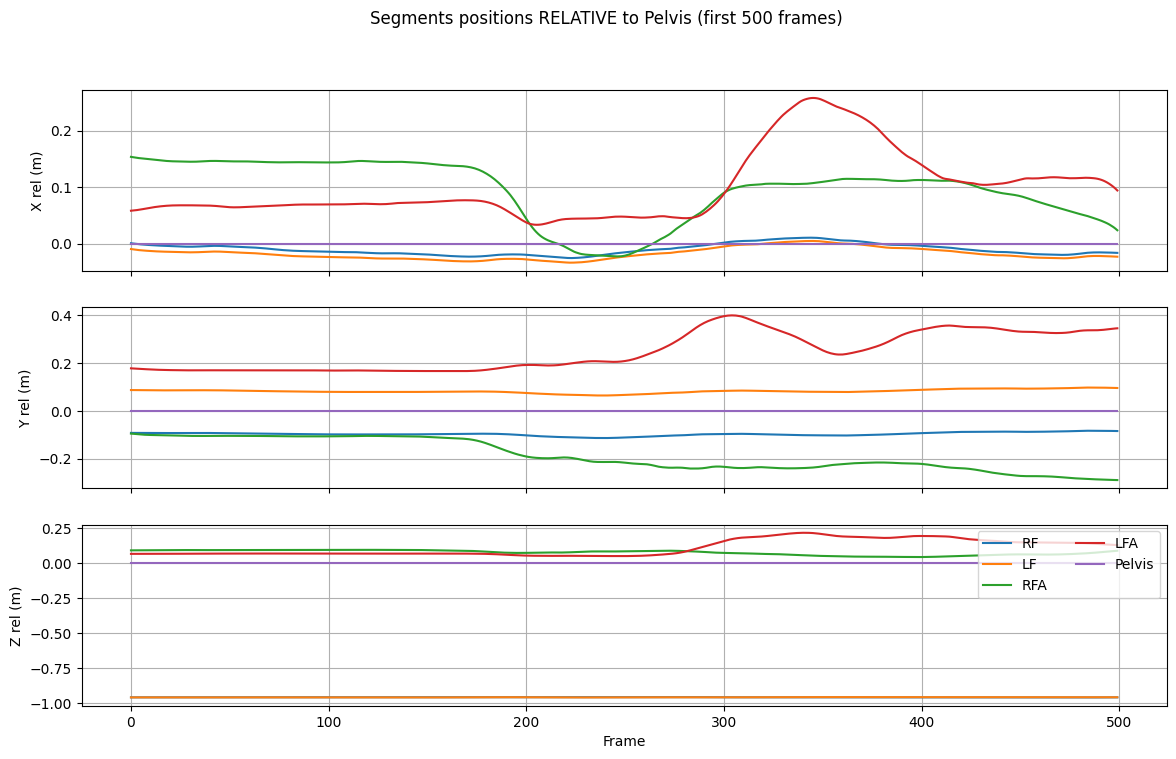


Per-segment summary stats


,segment,mean_dist_to_pelvis (m),mean_z_rel (m),z_std (m),z_min (m),z_max (m)
0,Pelvis,0.0000,0.0000,0.0000,0.0000,0.0000
1,RFA,0.2389,0.0814,0.0167,0.0437,0.1936
2,LFA,0.2372,0.0745,0.0213,0.0303,0.2176
3,RF,0.9523,-0.9326,0.0317,-0.9647,-0.8159
4,LF,0.9515,-0.9308,0.0364,-0.9661,-0.7645



Distance histograms (RFA vs LFA)


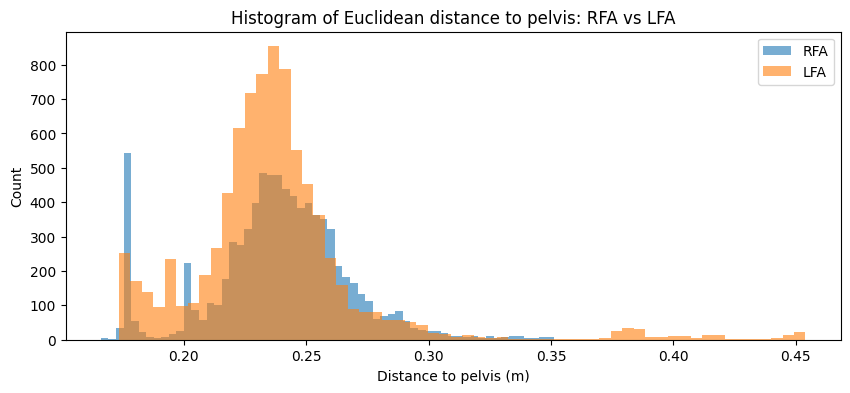


Candidate arm segments (periodicity diagnostics)
seg, mean_dist, zstd, zrange, periodicity (sorted by periodicity*zstd):
('LF', np.float64(0.9515277345620451), np.float64(0.03644271456896263), np.float64(0.20160599999999995), np.float64(34295.70649073788))
('RF', np.float64(0.9523388705751776), np.float64(0.03167267813584868), np.float64(0.148837), np.float64(25124.394390843678))
('LFA', np.float64(0.23715730070494423), np.float64(0.021327679897724664), np.float64(0.18728999999999996), np.float64(2295.0440556884223))
('RFA', np.float64(0.23894849762511822), np.float64(0.016721178333091596), np.float64(0.14985899999999996), np.float64(2830.24889737473))


,segment,mean_dist (m),z_std (m),z_range (m),periodicity
0,LF,0.95153,0.03644,0.20161,34295.70649
1,RF,0.95234,0.03167,0.14884,25124.39439
2,RFA,0.23895,0.01672,0.14986,2830.24890
3,LFA,0.23716,0.02133,0.18729,2295.04406



Inspect periodicity and std for RFA and LFA (quick view)


,segment,z_std (m),z_range (m),periodicity
0,RFA,0.01672,0.14986,2830.24890
1,LFA,0.02133,0.18729,2295.04406



Peak amplitude extraction for Z (per arm)


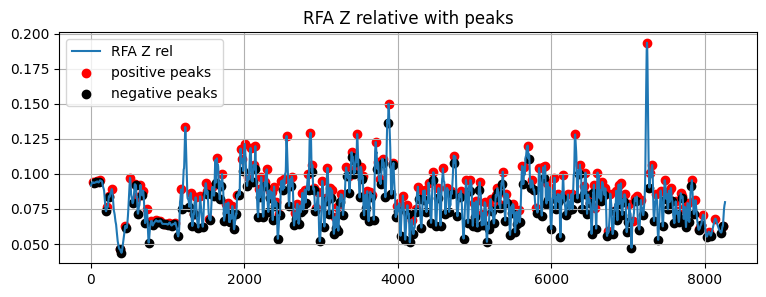

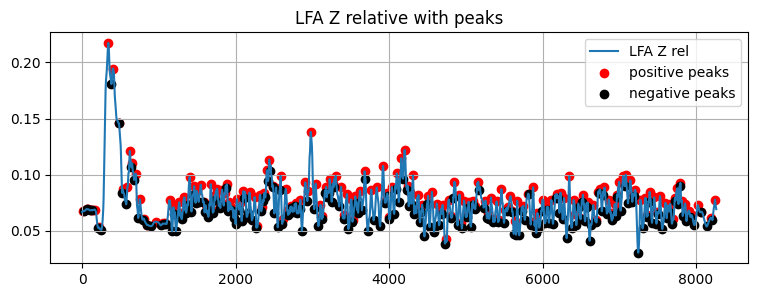

,segment,n_pos_peaks,n_neg_peaks,mean_amp (m)
0,RFA,197,211,0.01601
1,LFA,194,192,0.01551



Visualize a few example cycles (first 3 for RFA)


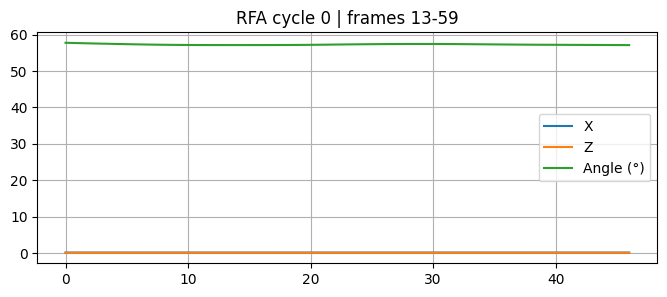

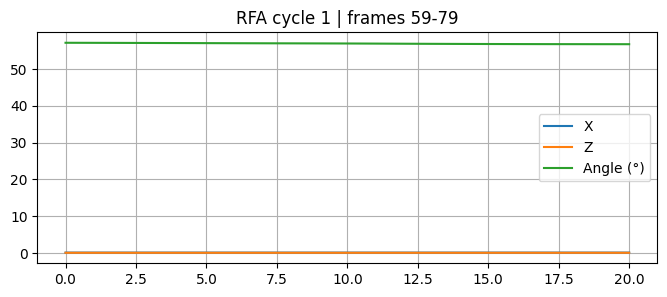

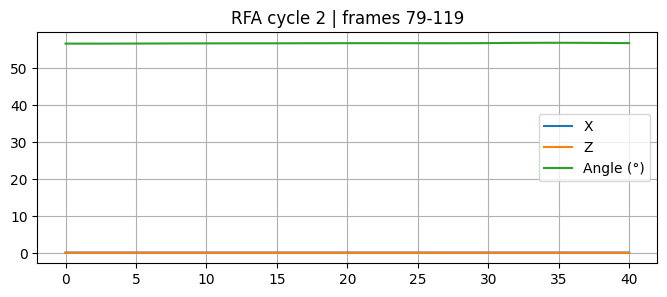


 Diagnostics complete.


In [48]:
# Running diagnostics

print("Quick segment plots (first 500 frames)")
plot_segments_vs_pelvis(data, frames=500)

# -----------------------------------------------------------------
print("\nPer-segment summary stats")
pos = data['pos']; pelvis = pos['Pelvis']
rows = []
for seg, arr in pos.items():
    rel = arr - pelvis
    mean_dist = np.mean(np.linalg.norm(arr - pelvis, axis=1))
    z_rel = rel[:,2]
    rows.append({
        "segment": seg,
        "mean_dist_to_pelvis (m)": mean_dist,
        "mean_z_rel (m)": np.mean(z_rel),
        "z_std (m)": np.std(z_rel),
        "z_min (m)": z_rel.min(),
        "z_max (m)": z_rel.max()
    })
df_stats = pd.DataFrame(rows).round(4)
display(df_stats)

# -----------------------------------------------------------------
print("\nDistance histograms (RFA vs LFA)")
plot_distance_histograms(data)

# -----------------------------------------------------------------
print("\nCandidate arm segments (periodicity diagnostics)")
candidates = find_arm_candidates(data, pelvis_key='Pelvis', fs=data['framerate'])
# Convert the tuple list returned by find_arm_candidates to a DataFrame
df_candidates = pd.DataFrame(candidates, columns=["segment","mean_dist (m)","z_std (m)","z_range (m)","periodicity"])
df_candidates = df_candidates.round(5).sort_values("periodicity", ascending=False).reset_index(drop=True)
display(df_candidates)

# -----------------------------------------------------------------
print("\nInspect periodicity and std for RFA and LFA (quick view)")
summary_rows = []
for seg in ['RFA','LFA']:
    rel = data['pos'][seg] - data['pos']['Pelvis']
    z = rel[:,2]
    summary_rows.append({
        "segment": seg,
        "z_std (m)": np.std(z),
        "z_range (m)": z.max() - z.min(),
        "periodicity": periodicity_score(z, fs=data['framerate'])
    })
df_summary = pd.DataFrame(summary_rows).round(5)
display(df_summary)

# -----------------------------------------------------------------
print("\nPeak amplitude extraction for Z (per arm)")
dist = 20  # frames; tune with expected cycle length
amp_rows = []
for seg in ['RFA','LFA']:
    rel = data['pos'][seg] - data['pos']['Pelvis']
    z = rel[:,2]
    amps, p_pos, p_neg = peaks_amp(z, fs=data['framerate'], distance_frames=dist)
    amp_rows.append({
        "segment": seg,
        "n_pos_peaks": len(p_pos),
        "n_neg_peaks": len(p_neg),
        "mean_amp (m)": np.nanmean(amps)
    })
    # Plot peaks on Z
    plt.figure(figsize=(9,3))
    plt.plot(z, label=f"{seg} Z rel")
    plt.scatter(p_pos, z[p_pos], color='r', label='positive peaks')
    plt.scatter(p_neg, z[p_neg], color='k', label='negative peaks')
    plt.title(f"{seg} Z relative with peaks")
    plt.legend(); plt.grid(True); plt.show()
df_amps = pd.DataFrame(amp_rows).round(5)
display(df_amps)

# -----------------------------------------------------------------
print("\nVisualize a few example cycles (first 3 for RFA)")
if 'p_pos' in locals() and len(p_pos) > 1:
    for i in range(min(3, len(p_pos)-1)):
        s = p_pos[i]; e = p_pos[i+1]
        rel = data['pos']['RFA'] - data['pos']['Pelvis']
        x = rel[s:e+1,0]; z = rel[s:e+1,2]
        angles_deg = np.degrees(np.arctan2(x, z))
        plt.figure(figsize=(8,3))
        plt.plot(x, label='X')
        plt.plot(z, label='Z')
        plt.plot(angles_deg, label='Angle (°)')
        plt.title(f'RFA cycle {i} | frames {s}-{e}')
        plt.legend(); plt.grid(True); plt.show()

print("\n Diagnostics complete.")


---

### Usage notes

1. Change `GLOBAL_CUTOFF_HZ` in the *Configuration* cell to alter the low-pass cutoff globally. The filter will be applied to positions, velocities (when derived or filtered), and accelerations consistently.
2. Run cells top-to-bottom. Use the debugging cell for inspecting specific files (set `file_path` and call `load_arm_data(file_path)` etc.).
3. If you want to run batch processing on your two folders (ataxia and Parkinson's), modify the folder paths and run the batch-processing cell:

```python
results_df_ataxia = batch_arm_analysis(folder_path_ataxia, ext='.txt', plot=False, cutoff=GLOBAL_CUTOFF_HZ)
save_results(results_df_ataxia, 'ataxia_arm_analysis_summary.csv')
```